# Exploratory Data Analysis on Wholesale price index

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Importing

In [2]:
file = pd.read_csv('project.csv')

In [3]:
df = pd.DataFrame(file)

## Data Understanding

The dataset has 763 rows and 27 columns, with each row representing a product and columns for product info and index values from 2012-13 to 2022-23.

In [4]:
df.shape

(869, 14)

In [5]:
df.head()

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023
0,Bajra,1101010104,0.08637,120.0,133.0,129.6,133.8,155.1,139.1,150.4,193.7,161.2,167.9,213.0
1,Masur,1101010204,0.05299,115.5,132.9,153.9,188.0,176.9,135.4,122.9,139.8,160.3,192.5,200.3
2,b1. VEGETABLES,1101020100,1.87448,123.5,163.6,159.4,145.7,138.0,164.0,150.2,197.0,203.6,204.5,215.0
3,Sweet Potato,1101020102,0.02051,100.2,104.7,117.8,71.0,71.0,71.0,69.5,68.6,69.9,82.6,99.7
4,Tomato,1101020107,0.28446,116.5,160.5,160.6,173.6,131.6,222.5,151.1,249.0,257.7,269.0,291.0


In [6]:
for i in df.columns:
    print(i)

COMM_NAME
COMM_CODE
COMM_WT
INDEX20122013
INDEX20132014
INDEX20142015
INDEX20152016
INDEX20162017
INDEX20172018
INDEX20182019
INDEX20192020
INDEX20202021
INDEX20212022
INDEX20222023


In [7]:
df.dtypes

COMM_NAME         object
COMM_CODE          int64
COMM_WT          float64
INDEX20122013    float64
INDEX20132014    float64
INDEX20142015    float64
INDEX20152016    float64
INDEX20162017    float64
INDEX20172018    float64
INDEX20182019    float64
INDEX20192020    float64
INDEX20202021    float64
INDEX20212022    float64
INDEX20222023    float64
dtype: object

In [8]:
 df.describe()

,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023
count,8.690000e+02,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000
mean,1.275946e+09,0.595963,106.347641,111.990449,115.661105,115.211968,117.046720,119.196087,122.758688,125.905293,127.237399,140.165132,149.627043
std,8.216739e+07,4.293702,9.487981,15.022158,16.871443,20.928116,23.141266,23.236776,24.368001,30.252793,30.525569,34.624997,39.602056
min,1.000000e+09,0.000020,38.300000,63.300000,59.700000,54.200000,48.300000,46.700000,30.900000,43.600000,42.200000,44.800000,48.200000
25%,1.301100e+09,0.022430,102.100000,104.500000,106.100000,104.100000,104.100000,106.300000,109.600000,109.600000,110.400000,119.300000,126.600000
50%,1.310070e+09,0.075530,105.100000,109.800000,113.500000,112.800000,113.900000,115.700000,119.800000,119.500000,121.200000,133.500000,141.400000
75%,1.316040e+09,0.241250,109.200000,116.300000,121.900000,123.600000,127.300000,129.800000,133.200000,137.500000,140.700000,155.900000,165.500000
max,2.000000e+09,100.000000,186.800000,280.200000,266.200000,255.500000,248.000000,236.500000,311.200000,350.800000,371.600000,372.200000,410.300000


## Data Preparation

In [9]:
df.isna().sum()

COMM_NAME        0
COMM_CODE        0
COMM_WT          0
INDEX20122013    0
INDEX20132014    0
INDEX20142015    0
INDEX20152016    0
INDEX20162017    0
INDEX20172018    0
INDEX20182019    0
INDEX20192020    0
INDEX20202021    0
INDEX20212022    0
INDEX20222023    0
dtype: int64

In [10]:
df.loc[df.duplicated()]

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023


In [11]:
df.loc[df.duplicated(subset=['COMM_NAME'])]

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023


In [12]:
df.loc[df.duplicated(subset=['COMM_CODE'])]

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023


In [13]:
df.loc[df.duplicated(subset=['INDEX20122013','INDEX20132014','INDEX20142015','INDEX20152016','INDEX20162017','INDEX20172018','INDEX20182019','INDEX20192020','INDEX20202021','INDEX20212022','INDEX20222023'
])].reset_index(drop=True)

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023
0,a. Manufacture of tobacco products,1303010000,0.51357,108.4,114.4,123.3,133.0,141.6,148.4,150.4,153.4,157.2,160.2,165.3
1,b. Metallic iron,1314020000,0.65301,103.0,97.2,96.5,77.0,79.4,99.4,117.8,107.7,113.3,147.7,165.9
2,Furnaces & Ovens,1318050001,0.00837,115.5,107.2,98.8,83.7,77.8,78.5,78.2,80.0,80.2,74.2,79.8
3,"Stringed musical instruments (incl. Santoor, G...",1322020001,0.00124,105.6,120.3,133.8,153.7,158.0,171.0,174.1,174.0,173.7,192.3,189.3
4,c. MILK,1101030000,4.43999,107.6,116.0,126.6,130.5,134.3,139.7,143.1,146.7,153.4,156.9,167.8
5,Electricity,1203000001,3.06409,100.5,103.6,105.7,105.3,104.2,103.7,109.6,111.8,109.6,117.4,143.3
6,a. Printing,1309010000,0.67622,110.5,118.7,126.2,136.1,141.1,143.7,146.6,150.6,153.8,157.8,172.5
7,"a. Manufacture of pharmaceuticals, medicinal c...",1311010000,1.99345,104.8,108.3,114.5,118.7,119.7,121.2,123.5,127.3,130.9,135.9,140.9
8,c. Manufacture of clay building materials,1313030000,0.12113,108.3,113.0,120.4,102.5,94.3,94.0,98.0,102.8,109.3,119.3,135.3
9,f. Alloy steel other than Stainless Steel- Shapes,1314060000,0.06671,106.3,99.8,102.1,88.7,85.6,97.3,111.7,102.8,108.3,133.7,146.9


In [14]:
df = df.loc[~df.duplicated(subset=['INDEX20122013','INDEX20132014','INDEX20142015','INDEX20152016','INDEX20162017','INDEX20172018','INDEX20182019','INDEX20192020','INDEX20202021','INDEX20212022','INDEX20222023'
])].reset_index(drop=True).copy()

In [15]:
df.shape

(845, 14)

In [16]:
df['Growth_Rate'] = ((df['INDEX20222023'] - df['INDEX20122013']) / df['INDEX20122013']) * 100

# Preview the updated dataset
df

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth_Rate
0,Bajra,1101010104,0.08637,120.0,133.0,129.6,133.8,155.1,139.1,150.4,193.7,161.2,167.9,213.0,77.500000
1,Masur,1101010204,0.05299,115.5,132.9,153.9,188.0,176.9,135.4,122.9,139.8,160.3,192.5,200.3,73.419913
2,b1. VEGETABLES,1101020100,1.87448,123.5,163.6,159.4,145.7,138.0,164.0,150.2,197.0,203.6,204.5,215.0,74.089069
3,Sweet Potato,1101020102,0.02051,100.2,104.7,117.8,71.0,71.0,71.0,69.5,68.6,69.9,82.6,99.7,-0.499002
4,Tomato,1101020107,0.28446,116.5,160.5,160.6,173.6,131.6,222.5,151.1,249.0,257.7,269.0,291.0,149.785408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,Foam and rubber mattress,1321010006,0.10674,109.4,119.8,131.7,138.5,137.1,153.6,158.8,172.7,171.5,205.7,225.4,106.032907
841,c. Manufacture of sports goods,1322030000,0.01238,106.5,106.6,113.9,118.0,124.7,126.0,127.4,129.7,132.0,140.4,150.5,41.314554
842,d. Manufacture of games and toys,1322040000,0.00476,105.4,112.1,118.2,123.3,125.2,128.2,132.2,136.9,142.4,150.9,159.0,50.853890
843,Playing Cards,1322040001,0.00207,104.2,110.7,117.8,124.2,126.9,130.3,132.6,134.0,141.6,150.1,162.5,55.950096


## Feature Understanding and Visualization

In [17]:
# Calculate the average of the Growth_Rate column
average_growth_rate = df['Growth_Rate'].mean()

# Display the result
print("The average growth rate is:", average_growth_rate)


The average growth rate is: 40.70620330531867


In [18]:
median_growth_rate = df['Growth_Rate'].median()
print("The median growth rate is:", median_growth_rate)

The median growth rate is: 34.64870067372473


In [19]:
base_year = df['INDEX20122013']
latest_year = df['INDEX20222023']

growth = (latest_year - base_year) / base_year * 100
df['Growth']=growth

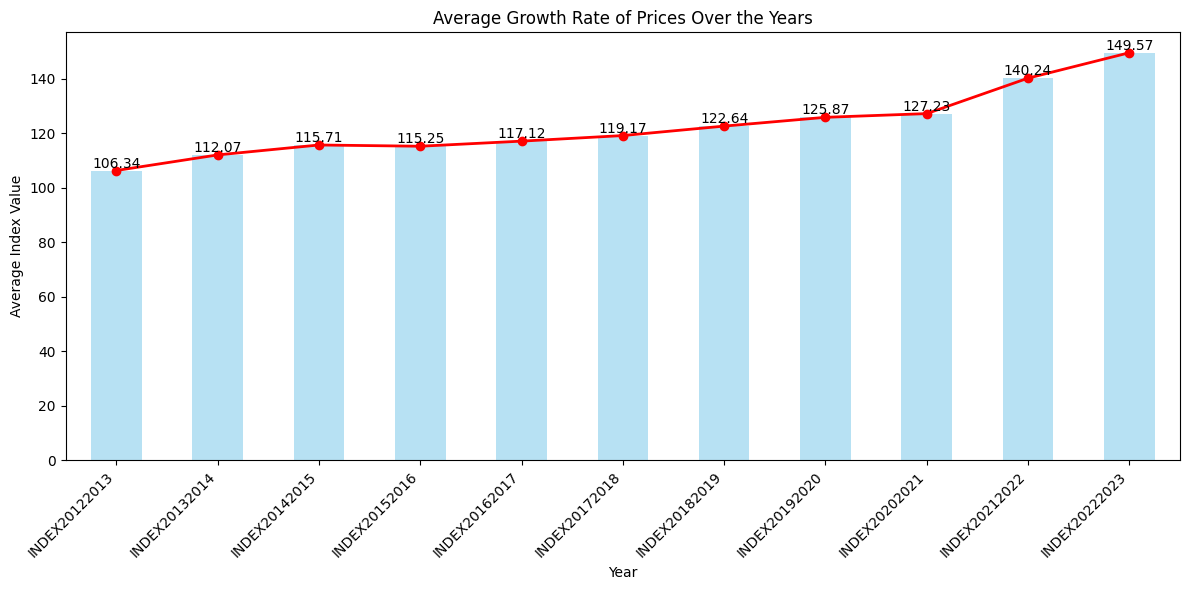

In [18]:


# Reshape data for plotting, focusing on columns with yearly indices
years = ['INDEX20122013', 'INDEX20132014', 'INDEX20142015', 'INDEX20152016', 
         'INDEX20162017', 'INDEX20172018', 'INDEX20182019', 'INDEX20192020', 
         'INDEX20202021', 'INDEX20212022', 'INDEX20222023']

# Compute the mean index value across all categories for each year
average_growth = df[years].mean()

# Plot combined growth rates over the years
plt.figure(figsize=(12, 6))
average_growth.plot(kind='bar', color='skyblue', alpha=0.6)
plt.plot(average_growth.index, average_growth.values, marker='o', color='red', linestyle='-', linewidth=2)

# Add plot labels and title
plt.title('Average Growth Rate of Prices Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Index Value')
plt.xticks(rotation=45, ha='right')

# Adding data labels
for i, value in enumerate(average_growth):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
 df['COMM_CODE'] = df['COMM_CODE'].astype(str)

In [ ]:
primary_article = df[df['COMM_CODE'].str[:3]=='110']

In [ ]:
primary_article

In [76]:
fuelpower = df[df['COMM_CODE'].str[:3]=='120']

In [77]:
fuelpower.reset_index(drop=True, inplace=True)

In [78]:
fuelpower

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
0,II FUEL & POWER,1200000000,13.15190,107.1,114.7,107.7,86.5,86.3,93.3,104.1,102.2,94.0,124.6,159.5,48.926237
1,b.) Non-Coking Coal G7 to G14 [GCV 3100 Kcal/k...,1201020002,0.88904,101.9,108.9,113.3,113.3,121.2,126.0,136.7,136.7,137.1,137.8,137.8,35.230618
2,c.) Non-Coking Coal G15 to G17 [GCV < 3100 Kca...,1201020003,0.01203,103.3,110.8,115.4,115.4,126.3,127.3,123.1,123.1,123.8,125.2,125.2,21.200387
3,c. Lignite,1201030000,0.09013,98.9,99.2,99.2,94.7,90.2,104.2,120.3,129.1,130.9,170.5,271.1,174.115268
4,(B). MINERAL OILS,1202000000,7.94968,110.9,121.6,108.7,73.9,73.3,82.5,96.7,92.3,79.2,126.2,172.9,55.906222
5,LPG,1202000001,0.64481,107.8,118.6,103.5,76.7,72.0,82.2,92.1,84.5,82.2,117.8,130.9,21.428571
6,Petrol,1202000002,1.60470,114.9,124.6,108.6,75.7,72.4,80.3,88.4,85.6,75.5,123.0,164.1,42.819843
7,Naphtha,1202000006,0.86678,109.8,119.4,103.0,66.9,66.5,74.5,92.6,82.3,65.1,115.8,135.9,23.770492
8,a. Coking Coal,1201010000,0.64703,100.0,101.2,101.4,101.4,108.2,134.1,132.9,138.1,141.8,143.0,143.4,43.400000
9,Bitumen,1202000007,0.22677,101.3,112.1,106.1,77.1,68.0,71.3,85.6,82.8,77.9,113.2,131.4,29.713722


In [79]:
MP = df[df['COMM_CODE'].str[:2]=='13']

In [80]:
MP.reset_index(drop=True, inplace=True)

In [81]:
MP

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
0,"Other meats, preserved/processed",1301010003,0.01934,110.2,119.5,126.6,131.4,134.6,141.1,148.1,156.1,149.5,158.1,171.8,55.898367
1,"Sauces of Vegetables (Tomato, Chilli, Soya & o...",1301030004,0.03397,103.6,102.1,112.0,113.6,116.8,111.1,108.2,109.0,117.4,121.3,126.6,22.200772
2,Vanaspati,1301040001,0.37937,103.4,101.7,103.3,97.1,107.0,111.1,119.8,126.3,141.5,170.8,167.8,62.282398
3,Castor Oil,1301040006,0.02955,92.9,97.2,103.4,97.4,95.9,106.8,112.7,116.3,111.0,139.9,165.6,78.256189
4,"Flour of cereals other than rice, wheat etc.",1301060005,0.00742,133.3,139.8,146.3,162.5,178.0,164.6,168.0,188.4,207.7,238.0,244.8,83.645911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,Foam and rubber mattress,1321010006,0.10674,109.4,119.8,131.7,138.5,137.1,153.6,158.8,172.7,171.5,205.7,225.4,106.032907
682,c. Manufacture of sports goods,1322030000,0.01238,106.5,106.6,113.9,118.0,124.7,126.0,127.4,129.7,132.0,140.4,150.5,41.314554
683,d. Manufacture of games and toys,1322040000,0.00476,105.4,112.1,118.2,123.3,125.2,128.2,132.2,136.9,142.4,150.9,159.0,50.853890
684,Playing Cards,1322040001,0.00207,104.2,110.7,117.8,124.2,126.9,130.3,132.6,134.0,141.6,150.1,162.5,55.950096


In [82]:
l = ['I    PRIMARY ARTICLES', 'II FUEL & POWER', 'III   MANUFACTURED PRODUCTS']
plt1 = df[df['COMM_NAME'].isin(l)]
plt1

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
27,II FUEL & POWER,1200000000,13.15190,107.1,114.7,107.7,86.5,86.3,93.3,104.1,102.2,94.0,124.6,159.5,48.926237
522,III MANUFACTURED PRODUCTS,1300000000,64.23054,105.3,108.5,111.2,109.2,110.7,113.8,117.9,118.3,121.5,135.0,142.6,35.422602
661,I PRIMARY ARTICLES,1100000000,22.61756,111.4,122.4,125.1,124.6,128.9,130.6,134.2,143.3,145.7,160.7,176.8,58.707361


In [83]:
l=list(plt1['COMM_NAME'])
print(type(l))

<class 'list'>


Categories like 'Food Articles', 'Fuel & Power' and 'Manufactured Products' comprise the major share of the overall WPI index.

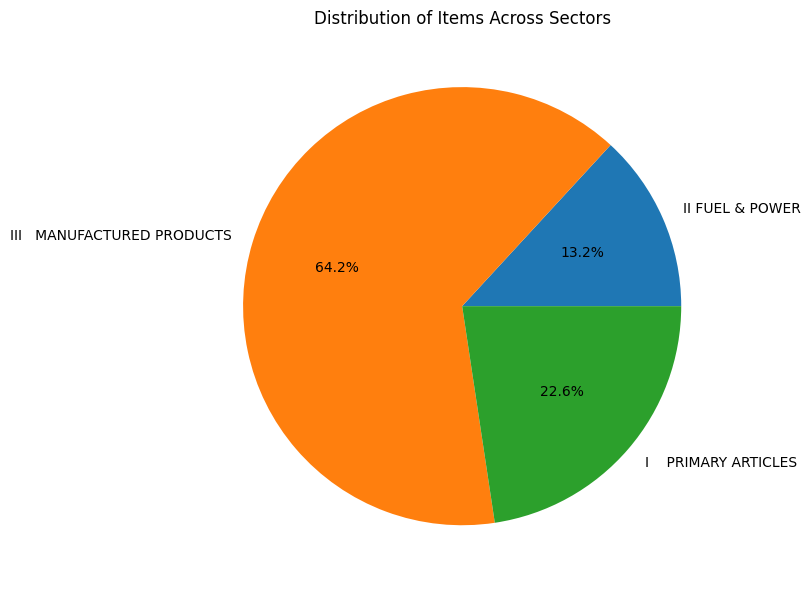

In [84]:
plt.figure(figsize=(10,6))
x = plt1['COMM_WT']
plt.pie(x, labels=l, autopct='%.1f%%')
plt.title('Distribution of Items Across Sectors')
plt.tight_layout()

<function matplotlib.pyplot.show(close=None, block=None)>

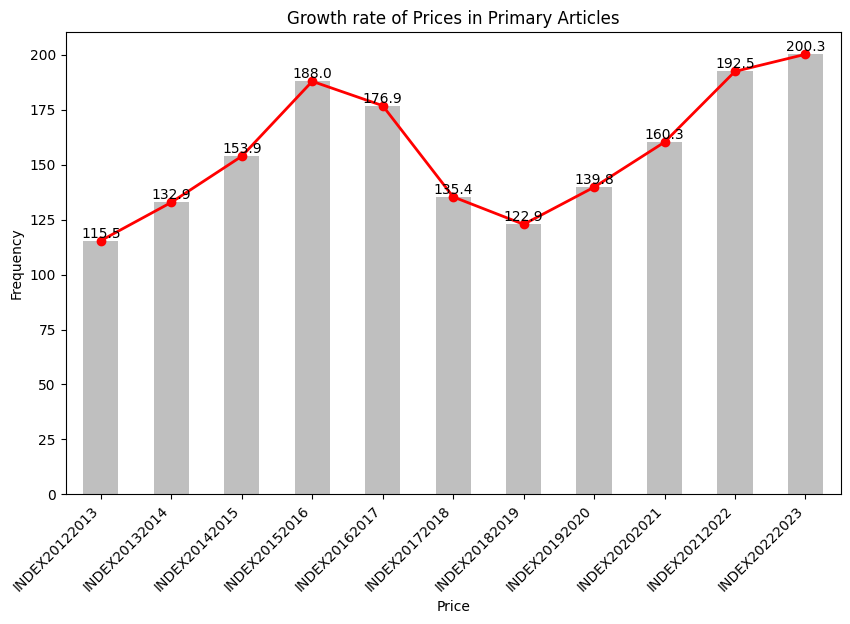

In [85]:
plt.figure(figsize=(10,6))
x = df.loc[1,['INDEX20122013','INDEX20132014','INDEX20142015','INDEX20152016','INDEX20162017','INDEX20172018','INDEX20182019','INDEX20192020','INDEX20202021','INDEX20212022','INDEX20222023'
]]
#plt.hist(x,bins=10, color='skyblue', density=0.1)
x.plot(kind='bar', alpha=0.5, color='grey')
plt.title('Growth rate of Prices in Primary Articles')
plt.plot(x, marker='o', color='red', linestyle='-', linewidth=2, markersize=6, label='Line Graph')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
for i, j in x.items():
    plt.text(i, j, f'{j}', ha='center', va='bottom')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

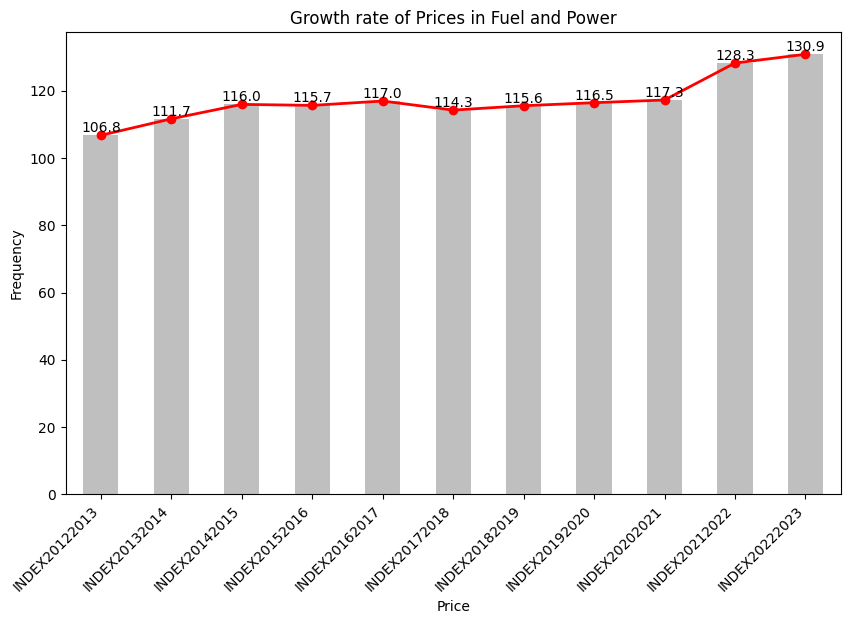

In [86]:
plt.figure(figsize=(10,6))
x = df.loc[138,['INDEX20122013','INDEX20132014','INDEX20142015','INDEX20152016','INDEX20162017','INDEX20172018','INDEX20182019','INDEX20192020','INDEX20202021','INDEX20212022','INDEX20222023'
]]
#plt.hist(x,bins=10, color='skyblue', density=0.1)
x.plot(kind='bar', alpha=0.5, color='grey')
plt.title('Growth rate of Prices in Fuel and Power')
plt.plot(x, marker='o', color='red', linestyle='-', linewidth=2, markersize=6, label='Line Graph')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
for i, j in x.items():
    plt.text(i, j, f'{j}', ha='center', va='bottom')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

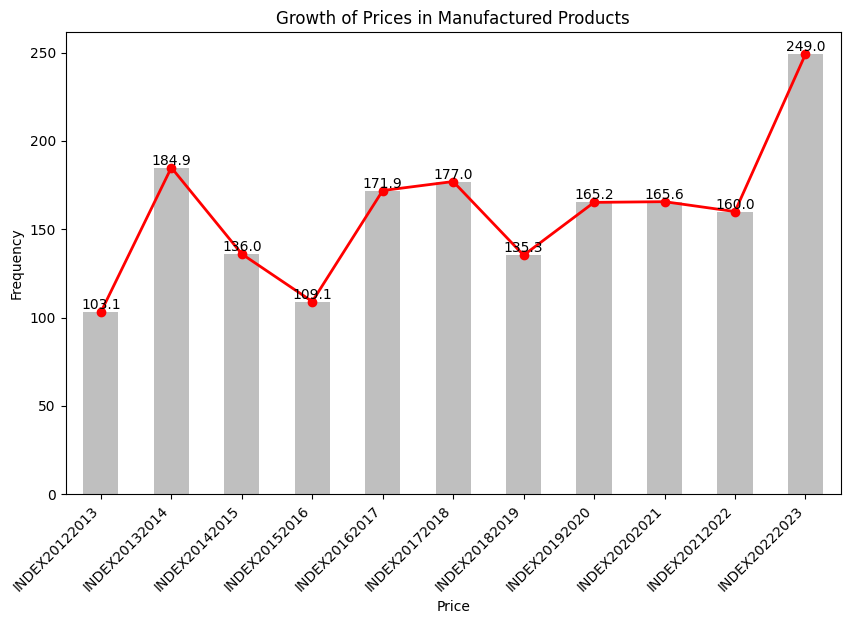

In [87]:
plt.figure(figsize=(10,6))
x = df.loc[158,['INDEX20122013','INDEX20132014','INDEX20142015','INDEX20152016','INDEX20162017','INDEX20172018','INDEX20182019','INDEX20192020','INDEX20202021','INDEX20212022','INDEX20222023'
]]
#plt.hist(x,bins=10, color='skyblue', density=0.1)
x.plot(kind='bar', alpha=0.5, color='grey')
plt.title('Growth of Prices in Manufactured Products')
plt.plot(x, marker='o', color='red', linestyle='-', linewidth=2, markersize=6, label='Line Graph')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
for i, j in x.items():
    plt.text(i, j, f'{j}', ha='center', va='bottom')
plt.show

In [88]:
primary_article_subset = primary_article[primary_article['COMM_NAME'].str[2:4]==').']
primary_article_subset.reset_index(drop=True, inplace=True)
primary_article_subset

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
0,(C). MINERALS,1103000000,0.83317,118.2,114.4,118.6,105.6,113.1,122.5,136.5,154.5,164.9,197.2,203.5,72.165821
1,(A). FOOD ARTICLES,1101000000,15.25585,110.9,124.5,131.5,134.9,140.3,143.2,143.7,155.8,160.7,167.3,179.5,61.857529
2,(B). NON-FOOD ARTICLES,1102000000,4.11894,113.3,118.4,115.1,118.2,122.2,119.6,123.1,128.7,130.5,158.1,172.1,51.897617
3,(D). CRUDE PETROLEUM & NATURAL GAS,1104000000,2.40960,109.4,119.0,103.5,76.6,73.1,73.0,92.4,85.3,70.4,110.3,158.4,44.789762


In [89]:
primary_article_subset.shape

(4, 15)

(array([0, 1, 2, 3]),
 [Text(0, 0, '(C).  MINERALS'),
  Text(1, 0, '(A).  FOOD ARTICLES'),
  Text(2, 0, '(B).  NON-FOOD ARTICLES'),
  Text(3, 0, '(D). CRUDE PETROLEUM & NATURAL GAS')])

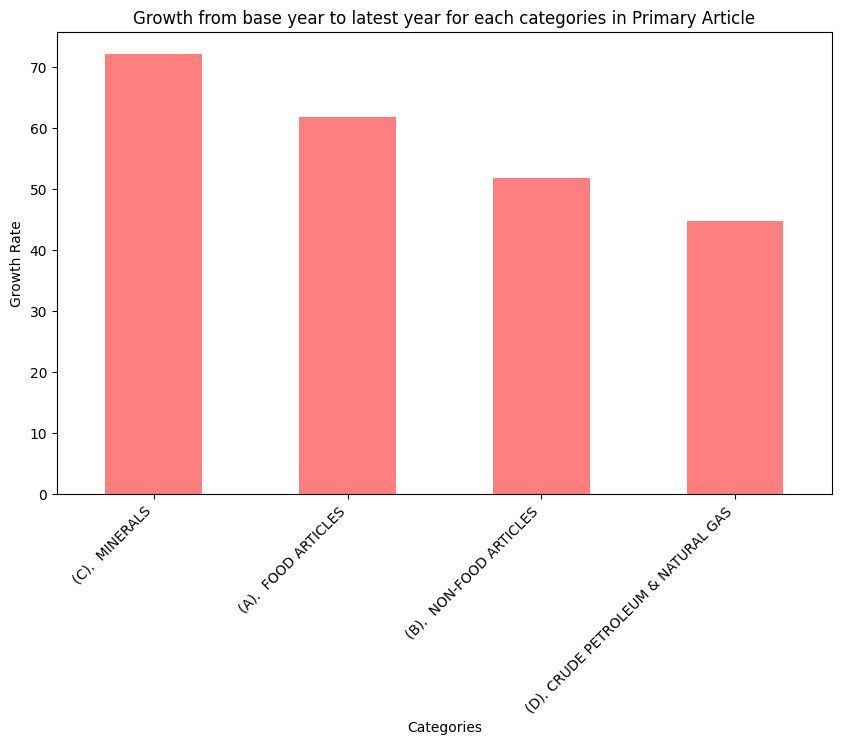

In [90]:
by = primary_article_subset['INDEX20122013']
ly = primary_article_subset['INDEX20222023']

plt.figure(figsize=(10,6))
growth = (ly - by) / by * 100
growth.index = primary_article_subset['COMM_NAME']

growth.plot(kind='bar', alpha=0.5, color='red')
plt.title('Growth from base year to latest year for each categories in Primary Article')
plt.xlabel('Categories')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45, ha='right')





In [91]:
growth


COMM_NAME
(C).  MINERALS                        72.165821
(A).  FOOD ARTICLES                   61.857529
(B).  NON-FOOD ARTICLES               51.897617
(D). CRUDE PETROLEUM & NATURAL GAS    44.789762
dtype: float64

In [92]:
fuelpower_subset = fuelpower[fuelpower['COMM_NAME'].str[2:4]==').']
fuelpower_subset.reset_index(drop=True, inplace=True)
fuelpower_subset

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
0,(B). MINERAL OILS,1202000000,7.94968,110.9,121.6,108.7,73.9,73.3,82.5,96.7,92.3,79.2,126.2,172.9,55.906222
1,(C). ELECTRICITY,1203000000,3.06409,100.5,103.6,105.7,105.3,104.2,103.7,109.6,111.8,109.6,117.4,143.3,42.587065
2,(A). COAL,1201000000,2.13813,102.1,104.8,106.7,106.5,109.0,118.7,123.3,125.3,126.6,129.0,133.3,30.558276


In [93]:
fuelpower_subset.shape

(3, 15)

(array([0, 1, 2]),
 [Text(0, 0, '(B). MINERAL OILS'),
  Text(1, 0, '(C). ELECTRICITY'),
  Text(2, 0, '(A). COAL')])

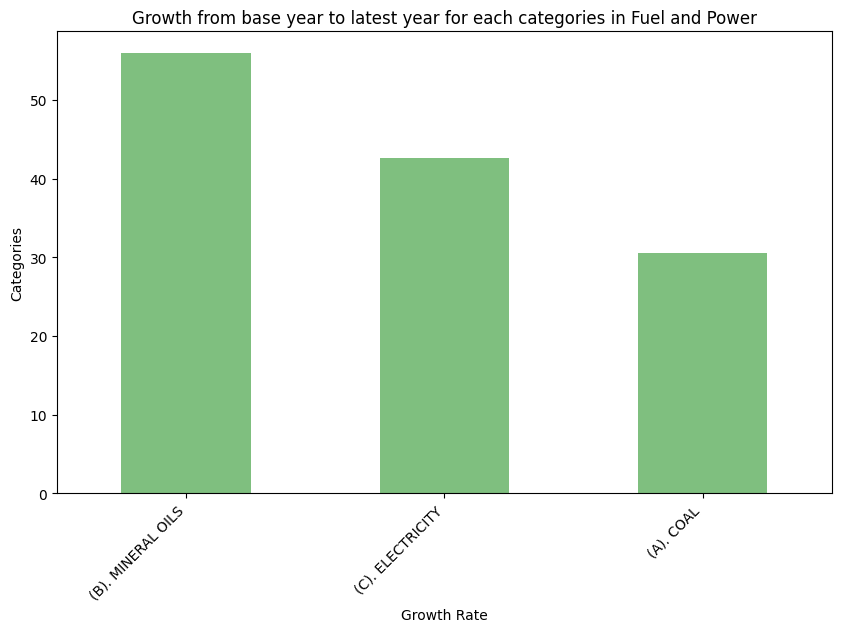

In [94]:
by = fuelpower_subset['INDEX20122013']
ly = fuelpower_subset['INDEX20222023']

plt.figure(figsize=(10,6))
growth = (ly - by) / by * 100
growth.index = fuelpower_subset['COMM_NAME']

growth.plot(kind='bar', alpha=0.5, color='green')
plt.title('Growth from base year to latest year for each categories in Fuel and Power')
plt.ylabel('Categories')
plt.xlabel('Growth Rate')
plt.xticks(rotation=45, ha='right')


In [95]:



growth

COMM_NAME
(B). MINERAL OILS    55.906222
(C). ELECTRICITY     42.587065
(A). COAL            30.558276
dtype: float64

In [96]:
MP_subset = MP[MP['COMM_NAME'].str[2:4]==').']
MP_subset.reset_index(drop=True, inplace=True)
MP_subset

,COMM_NAME,COMM_CODE,COMM_WT,INDEX20122013,INDEX20132014,INDEX20142015,INDEX20152016,INDEX20162017,INDEX20172018,INDEX20182019,INDEX20192020,INDEX20202021,INDEX20212022,INDEX20222023,Growth
0,(C). MANUFACTURE OF TOBACCO PRODUCTS,1303000000,0.51357,108.4,114.4,123.3,133.0,141.6,148.4,150.4,153.4,157.2,160.2,165.3,52.490775
1,"(P). MANUFACTURE OF COMPUTER, ELECTRONIC AND O...",1316000000,2.00875,101.0,103.0,107.4,108.0,108.3,110.1,111.8,110.4,109.8,113.7,116.6,15.445545
2,(A). MANUFACTURE OF FOOD PRODUCTS,1301000000,9.12173,108.7,114.1,116.2,114.5,125.4,127.4,128.6,133.9,141.4,157.9,165.3,52.069917
3,(E). MANUFACTURE OF WEARING APPAREL,1305000000,0.81414,112.2,117.7,122.6,128.7,131.0,136.9,138.8,138.3,138.6,143.1,148.7,32.531194
4,"(O). MANUFACTURE OF FABRICATED METAL PRODUCTS,...",1315000000,3.15498,103.2,103.0,105.8,105.9,105.1,109.5,115.1,115.5,115.9,130.5,139.0,34.689922
5,(I). PRINTING AND REPRODUCTION OF RECORDED MEDIA,1309000000,0.67622,110.5,118.7,126.2,136.1,141.1,143.7,146.6,150.6,153.8,157.8,172.5,56.108597
6,(J). MANUFACTURE OF CHEMICALS AND CHEMICAL PRO...,1310000000,6.46505,108.3,113.3,116.1,112.6,111.0,112.5,119.1,117.5,118.2,133.5,145.4,34.256694
7,"(K). MANUFACTURE OF PHARMACEUTICALS, MEDICINAL...",1311000000,1.99345,104.8,108.3,114.5,118.7,119.7,121.2,123.5,127.3,130.9,135.9,140.9,34.446565
8,(G). MANUFACTURE OF WOOD AND OF PRODUCTS OF WO...,1307000000,0.77181,110.9,118.8,124.6,130.0,129.8,131.5,133.5,133.7,134.6,141.0,143.2,29.125338
9,(H). MANUFACTURE OF PAPER AND PAPER PRODUCTS,1308000000,1.11322,103.6,110.2,114.0,112.7,113.6,118.9,123.3,121.1,121.7,137.5,152.0,46.718147


In [97]:
MP_subset.shape

(22, 15)

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

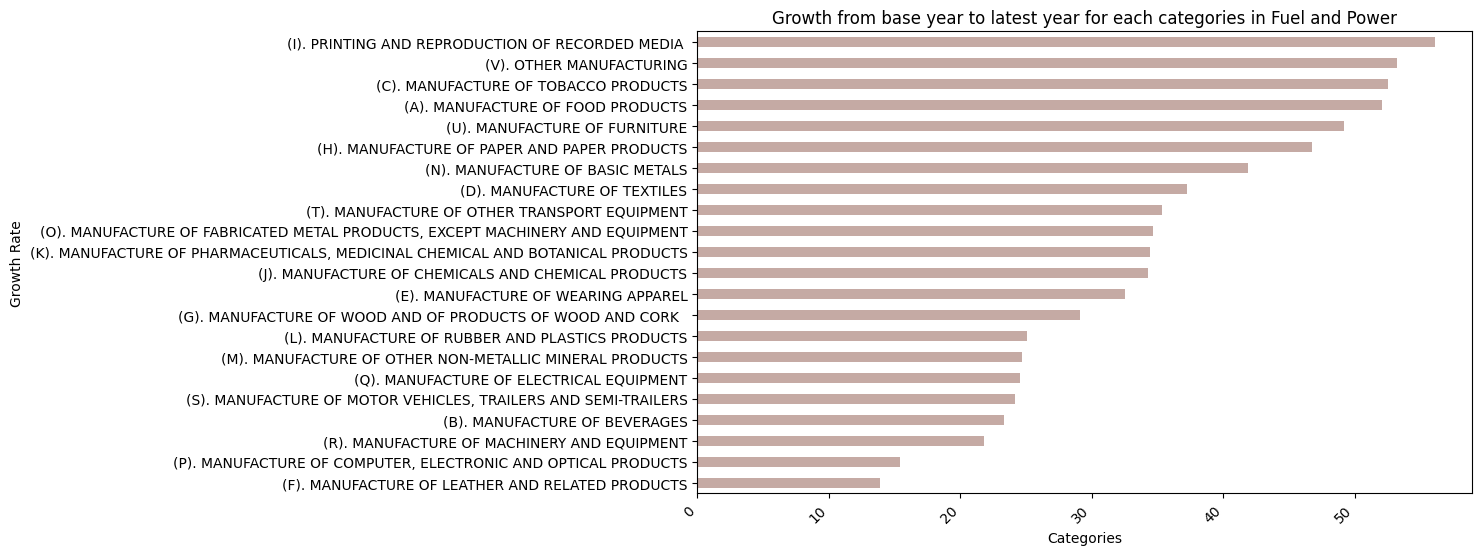

In [98]:
by = MP_subset['INDEX20122013']
ly = MP_subset['INDEX20222023']

plt.figure(figsize=(10,6))
growth = (ly - by) / by * 100
growth.index = MP_subset['COMM_NAME']
growth = growth.sort_values(ascending=True)
growth.plot(kind='barh', alpha=0.5, color='C5')
plt.title('Growth from base year to latest year for each categories in Fuel and Power')
plt.xlabel('Categories')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45, ha='right')

In [99]:
growth.sort_values(ascending=True)

COMM_NAME
(F). MANUFACTURE OF LEATHER AND RELATED PRODUCTS                                  13.886300
(P). MANUFACTURE OF COMPUTER, ELECTRONIC AND OPTICAL PRODUCTS                     15.445545
(R). MANUFACTURE OF MACHINERY AND EQUIPMENT                                       21.814672
(B). MANUFACTURE OF BEVERAGES                                                     23.349282
(S). MANUFACTURE OF MOTOR VEHICLES, TRAILERS AND SEMI-TRAILERS                    24.124514
(Q). MANUFACTURE OF ELECTRICAL EQUIPMENT                                          24.564797
(M). MANUFACTURE OF OTHER NON-METALLIC MINERAL PRODUCTS                           24.720149
(L). MANUFACTURE OF RUBBER AND PLASTICS PRODUCTS                                  25.072324
(G). MANUFACTURE OF WOOD AND OF PRODUCTS OF WOOD AND CORK                         29.125338
(E). MANUFACTURE OF WEARING APPAREL                                               32.531194
(J). MANUFACTURE OF CHEMICALS AND CHEMICAL PRODUCTS                   

Some specific products like Tomatoes, almonds, spices, edible oils, metal products etc. witnessed very high percentage growth (>100%) from 2012-13 to 2022-23.

In [100]:
high_growth = df[df['Growth'] > 100][['COMM_NAME', 'COMM_CODE', 'COMM_WT','Growth']]
high_growth.shape

(43, 4)

In [101]:
high_growth

,COMM_NAME,COMM_CODE,COMM_WT,Growth
4,Tomato,1101020107,0.28446,149.785408
7,Drumstick,1101020120,0.01823,168.046198
12,Walnut,1101020220,0.02599,110.431034
15,Betelnut/Arecanut,1101050006,0.08487,159.095284
19,a. FIBRES,1102010000,0.83931,105.050505
20,Raw Jute,1102010002,0.05453,145.421578
26,Copper Concentrate,1103010006,0.33393,103.462838
30,c. Lignite,1201030000,0.09013,174.115268
153,Barley,1101010106,0.01437,101.989619
158,Tapioca,1101020104,0.07213,141.513094


Top five products whose price values has incresed the most in primary article

In [102]:
top = primary_article.nlargest(5,'Growth')[['COMM_NAME', 'COMM_CODE', 'COMM_WT','Growth']]
top

,COMM_NAME,COMM_CODE,COMM_WT,Growth
672,Guava,1101020210,0.04560,332.837838
180,Jasmine,1102040002,0.03063,307.852883
690,Garnet,1103020003,0.00139,235.621891
509,Ginger (Dry),1101050005,0.02098,200.115340
344,Chillies (Dry),1101050002,0.14056,179.186603


Top five products whose price values has incresed the most in Fuel and Power

In [103]:
top = fuelpower.nlargest(5,'Growth')[['COMM_NAME', 'COMM_CODE', 'COMM_WT','Growth']]
top

,COMM_NAME,COMM_CODE,COMM_WT,Growth
12,Kerosene,1202000003,0.18685,275.910364
11,Petroleum Coke,1202000010,0.04663,195.372233
3,c. Lignite,1201030000,0.09013,174.115268
19,HSD,1202000005,3.09548,71.505376
17,ATF,1202000004,0.31991,67.406750


Top five products whose price values has incresed the most in Manufactured Products

In [104]:
top = MP.nlargest(5,'Growth')[['COMM_NAME', 'COMM_CODE', 'COMM_WT','Growth']]
top

,COMM_NAME,COMM_CODE,COMM_WT,Growth
318,"Fungicide, liquid",1310040003,0.00357,191.881566
348,Iron/steel hinges,1315050003,0.00300,150.824442
434,Nitric Acid,1310010018,0.02048,137.368923
311,Camphor,1310010015,0.00751,126.327684
527,Steel shutter gate,1321010003,0.06840,123.348837


Overall, the WPI index has risen by around 40% from 2012-13 to 2022-23 

In [105]:
index_2012 = (df['INDEX20122013'] * df['COMM_WT'] / 100).sum()
index_2022 = (df['INDEX20222023'] * df['COMM_WT'] / 100).sum()

growth_rate_overall = (index_2022 - index_2012) / index_2012 * 100

print("WPI Growth Rate:", growth_rate_overall)

WPI Growth Rate: 43.46634391973801


The WPI index has risen by around 16.7% from the past three years indicating rising inflationary pressures.

In [106]:
index_2020 = (df['INDEX20202021'] * df['COMM_WT'] / 100).sum()
index_2022 = (df['INDEX20222023'] * df['COMM_WT'] / 100).sum()

growth_rate_20_22 = (index_2022 - index_2020) / index_2020 * 100

print("WPI Growth Rate in the past three years:", growth_rate_20_22)

WPI Growth Rate in the past three years: 21.826454584577572
